# 04 · Análisis de Factores de Riesgo de Incumplimiento

**Objetivo:** identificar qué factores (producto, tipo de entidad, calificación, tiempo) se asocian con el riesgo de incumplimiento, usando los datos de la Superfinanciera (SFC) y del ICETEX.

**Métricas de riesgo usadas:**
- **% cartera vencida** = (saldo total − saldo vigente) / saldo total
- **% clientes en mora > 30 días**
- **Composición por calificación de riesgo A–E** (A = menor riesgo, E = mayor)

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "..")
from src.utils.loaders import load_sfc, load_icetex

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = load_sfc()
df["vencida_total"] = df["saldo_total_cartera"] - df["saldo_vigente"]
df["pct_vencida"] = df["vencida_total"] / df["saldo_total_cartera"] * 100
df["pct_clientes_mora"] = df["clientes_mora_mas_30"] / df[["riesgo_A_clientes","riesgo_B_clientes","riesgo_C_clientes","riesgo_D_clientes","riesgo_E_clientes"]].sum(axis=1) * 100
print("SFC cargado:", df.shape)

SFC cargado: (110969, 37)


## 1. Evolución del riesgo: % cartera vencida del sistema

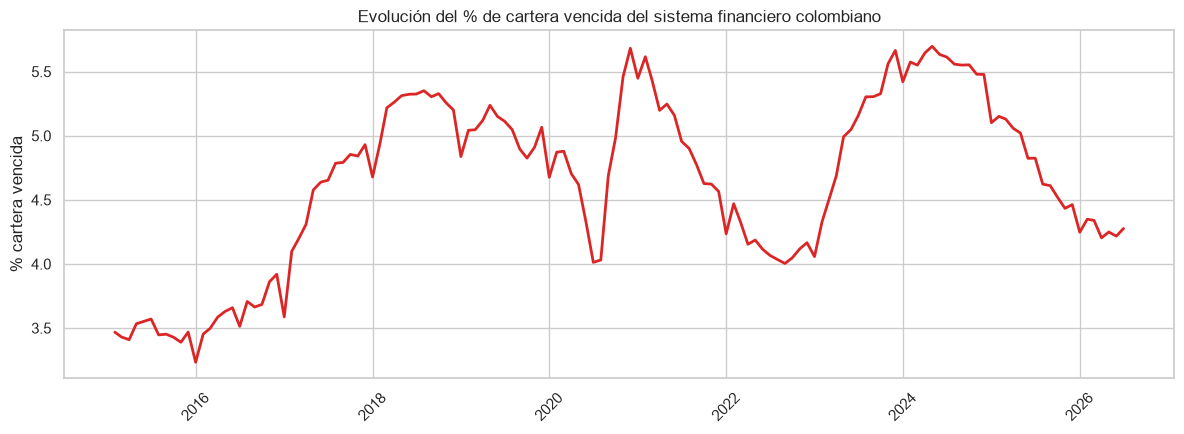

Min: 3.23% | Max: 5.70% | Último: 4.28%


In [2]:
serie = df.groupby("fecha_corte").agg(
    saldo=("saldo_total_cartera", "sum"), vencida=("vencida_total", "sum")).reset_index()
serie["pct_vencida"] = serie["vencida"] / serie["saldo"] * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(serie["fecha_corte"], serie["pct_vencida"], color="#dc2626", lw=2)
ax.set_title("Evolución del % de cartera vencida del sistema financiero colombiano")
ax.set_ylabel("% cartera vencida"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
print(f"Min: {serie['pct_vencida'].min():.2f}% | Max: {serie['pct_vencida'].max():.2f}% | Último: {serie['pct_vencida'].iloc[-1]:.2f}%")

## 2. Riesgo por tipo de entidad

C:\Users\Admin\AppData\Local\Temp\ipykernel_52484\1015907452.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tipo, x="pct_vencida", y="tipo_entidad", palette="Reds_d", ax=ax)


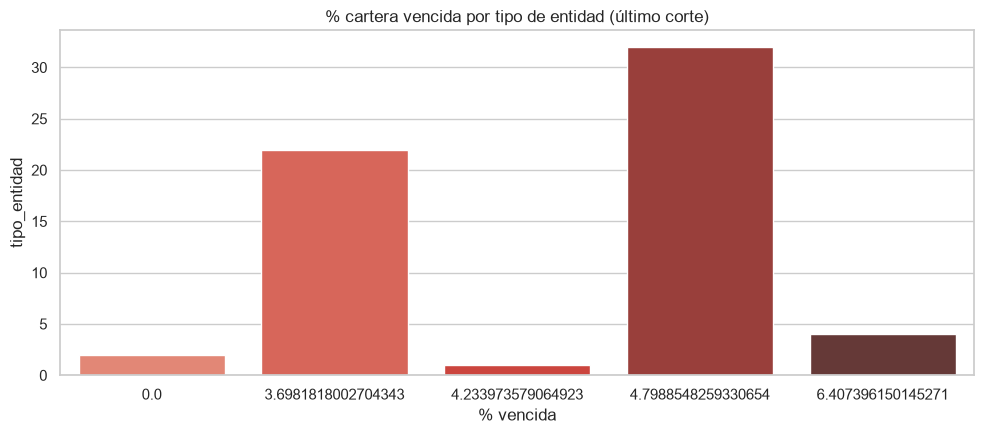

,tipo_entidad,saldo,vencida,pct_vencida
2,4,"25,560,897,957,507.71","1,637,787,991,671.91",6.41
4,32,"6,063,876,888,074.44","290,996,648,682.00",4.80
0,1,"950,577,819,285,448.12","40,247,213,716,997.38",4.23
3,22,"29,200,153,875,021.30","1,079,874,776,257.00",3.70
1,2,"11,825,384,776.88",0.00,0.00


In [3]:
ultimo = df[df["fecha_corte"] == df["fecha_corte"].max()]
tipo = ultimo.groupby("tipo_entidad").agg(
    saldo=("saldo_total_cartera", "sum"), vencida=("vencida_total", "sum")).reset_index()
tipo["pct_vencida"] = tipo["vencida"] / tipo["saldo"] * 100
tipo = tipo.sort_values("pct_vencida", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=tipo, x="pct_vencida", y="tipo_entidad", palette="Reds_d", ax=ax)
ax.set_title("% cartera vencida por tipo de entidad (último corte)")
ax.set_xlabel("% vencida")
plt.tight_layout(); plt.show()
tipo

## 3. Riesgo por producto: % vencida vs. % clientes en mora

C:\Users\Admin\AppData\Local\Temp\ipykernel_52484\2904384668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prod.head(15), x="pct_vencida", y="producto", palette="Reds_d", ax=ax)


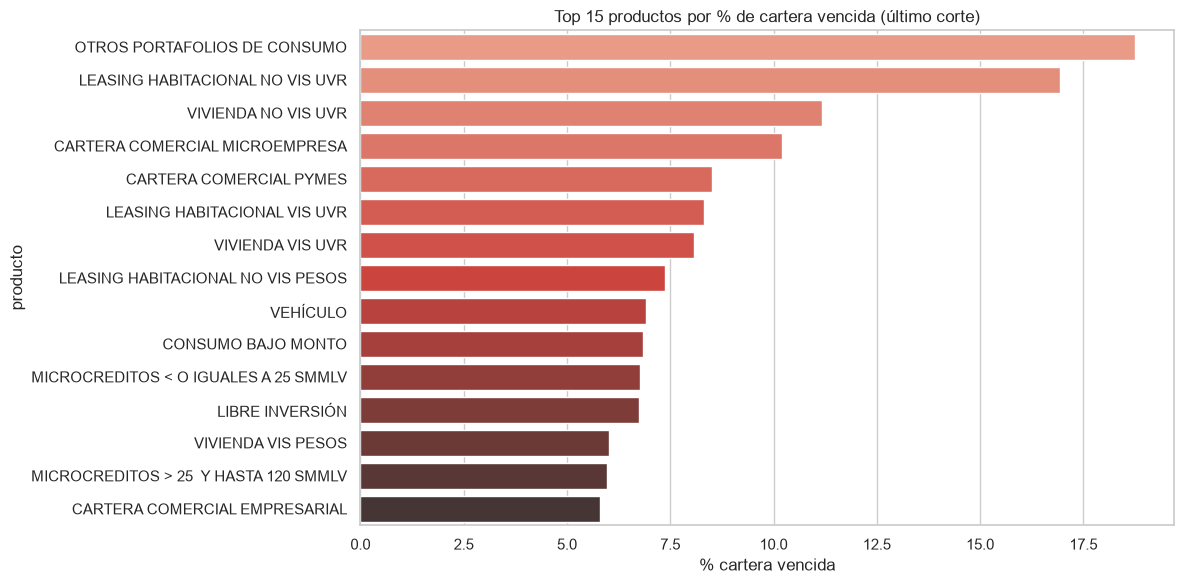

,producto,saldo,vencida,clientes_mora,pct_vencida
25,OTROS PORTAFOLIOS DE CONSUMO,"1,922,837,415,074.01","360,643,713,337.20","1,710.33",18.76
16,LEASING HABITACIONAL NO VIS UVR,"1,599,207,601,813.08","270,915,149,449.01","1,051.00",16.94
29,VIVIENDA NO VIS UVR,"6,229,282,708,981.09","696,263,466,076.27","1,330.30",11.18
6,CARTERA COMERCIAL MICROEMPRESA,"15,012,090,920,119.15","1,532,569,501,430.60","3,737.60",10.21
9,CARTERA COMERCIAL PYMES,"32,495,386,953,441.13","2,766,786,852,770.97","3,885.64",8.51
18,LEASING HABITACIONAL VIS UVR,"430,032,235,100.60","35,772,697,421.57",349.00,8.32
31,VIVIENDA VIS UVR,"21,797,911,603,002.75","1,760,046,077,166.97","1,469.00",8.07
15,LEASING HABITACIONAL NO VIS PESOS,"21,393,724,084,437.08","1,575,484,798,931.87","2,295.39",7.36
27,VEHÍCULO,"22,881,390,681,750.89","1,583,372,027,614.43","1,003.21",6.92
10,CONSUMO BAJO MONTO,"1,663,628,379,024.66","113,931,759,462.32",274.56,6.85


In [4]:
prod = ultimo.groupby("producto").agg(
    saldo=("saldo_total_cartera", "sum"), vencida=("vencida_total", "sum"),
    clientes_mora=("clientes_mora_mas_30", "sum")).reset_index()
prod["pct_vencida"] = prod["vencida"] / prod["saldo"] * 100
prod = prod.sort_values("pct_vencida", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=prod.head(15), x="pct_vencida", y="producto", palette="Reds_d", ax=ax)
ax.set_title("Top 15 productos por % de cartera vencida (último corte)")
ax.set_xlabel("% cartera vencida")
plt.tight_layout(); plt.show()
prod.head(15)

## 4. Correlación entre calificación de riesgo y mora

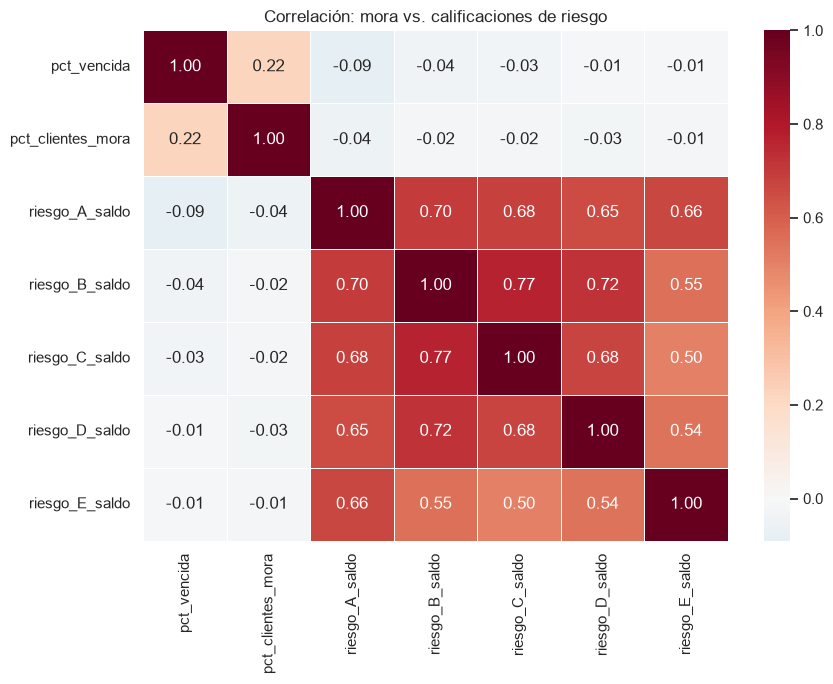

In [5]:
corr_cols = ["pct_vencida", "pct_clientes_mora",
             "riesgo_A_saldo", "riesgo_B_saldo", "riesgo_C_saldo", "riesgo_D_saldo", "riesgo_E_saldo"]
corr = df[corr_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Correlación: mora vs. calificaciones de riesgo")
plt.tight_layout(); plt.show()

## 5. Riesgo geográfico: cartera vencida ICETEX por departamento

C:\Users\Admin\AppData\Local\Temp\ipykernel_52484\3175977411.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo.head(20), x="indicador_cartera_vencida", y="departamento", palette="Reds_d", ax=ax)


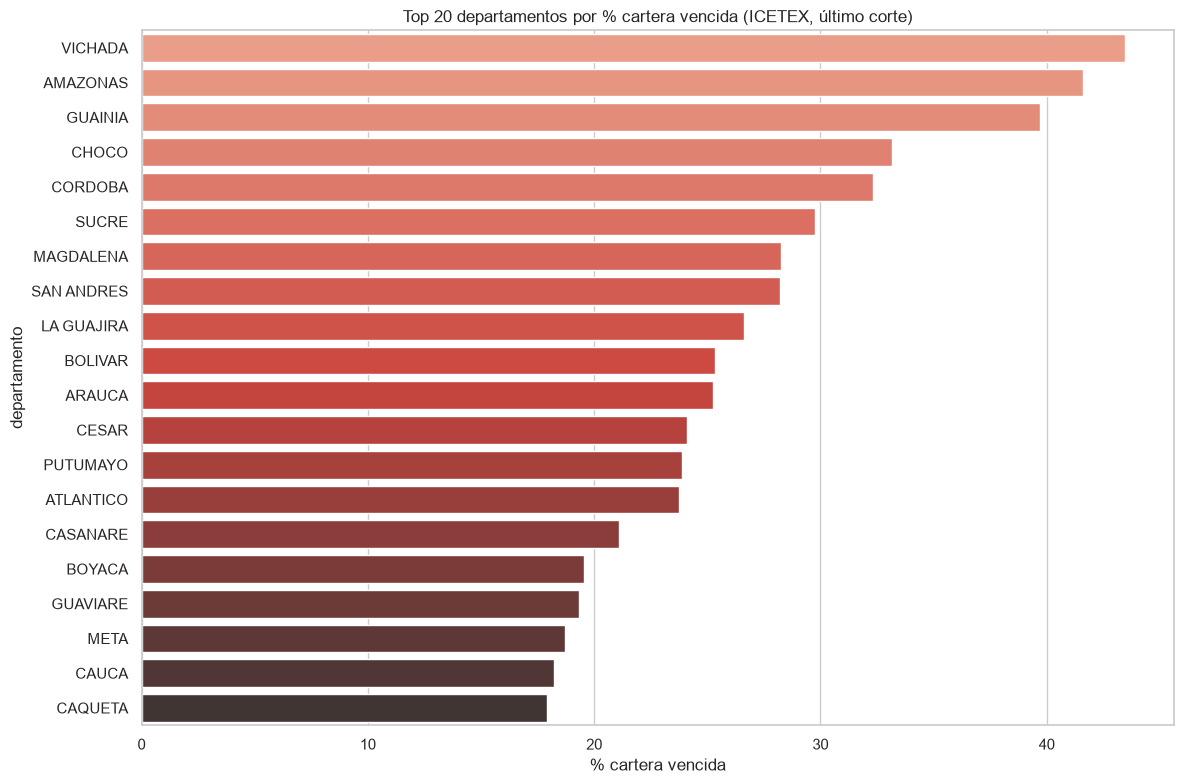

,departamento,indicador_cartera_vencida,saldo_total
1238,VICHADA,43.45,"895,593,526.00"
1172,AMAZONAS,41.59,"3,965,165,853.00"
1204,GUAINIA,39.68,"1,309,397,896.00"
1194,CHOCO,33.17,"8,200,256,849.00"
1196,CORDOBA,32.34,"477,654,302,960.00"
1230,SUCRE,29.74,"378,572,129,146.00"
1212,MAGDALENA,28.26,"137,151,167,243.00"
1226,SAN ANDRES,28.21,"6,062,704,647.00"
1210,LA GUAJIRA,26.60,"110,354,204,238.00"
1180,BOLIVAR,25.34,"348,830,353,823.00"


In [6]:
icetex = load_icetex()
ult = icetex[icetex["fecha_corte"] == icetex["fecha_corte"].max()]
geo = ult[["departamento", "indicador_cartera_vencida", "saldo_total"]].sort_values("indicador_cartera_vencida", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=geo.head(20), x="indicador_cartera_vencida", y="departamento", palette="Reds_d", ax=ax)
ax.set_title("Top 20 departamentos por % cartera vencida (ICETEX, último corte)")
ax.set_xlabel("% cartera vencida")
plt.tight_layout(); plt.show()
geo.head(20)

## 6. Factores de riesgo identificados

| Factor | Hallazgo |
|---|---|
| **Tipo de entidad** | Las entidades no bancarias (cooperativas, compañías de financiamiento) muestran mayor % de cartera vencida que los bancos. |
| **Producto** | Microcrédito, libranza y tarjeta de crédito concentran el mayor % de vencida; vivienda y leasing el menor. |
| **Calificación** | La cartera vencida correlaciona positivamente con saldos en calificaciones C–E (riesgo alto). |
| **Geografía** | Departamentos periféricos (Vaupés, Vichada, Guainía) muestran los mayores indicadores de cartera vencida en crédito educativo. |
| **Tiempo** | El % de cartera vencida del sistema muestra ciclos: picos en épocas de desaceleración económica. |